# GOAT Example: Two-Qubit Rydberg Gates for Neutral Atom Quantum Computers

**GOAT Overview**

This notebook walks through an example of using the $\texttt{goat\_qoc}$ library to produce optimal pulses for Rydberg gates in neutral atom quantum computers. A comprehensive overview of the GOAT algorithm can be found in Ref. [1], though a brief summary is given here for completeness. To specify a quantum optimal control (QOC) task for GOAT in its original description from Ref. [1], one must define the system Hamiltonian in the following way,
$$H(\overline{\alpha},t)=H_0+\sum_{k=0}^C c(\overline{\alpha},t)H_k$$
where $H_0$ is a constant drift Hamiltonian, the $H_k$'s are the set of control Hamiltonians, and the $c_k$'s are control functions characterized by the control parameters $\overline{\alpha}$. The cost function can be defined flexibily, as will be demonstrated in this notebook, but for now, the simplest example is to use the SU distance for gate fidelity, defined as,
$$\mathcal{F}(\overline{\alpha})=\frac{1}{\text{dim}(U)}\left|\text{Tr}\left(U^\dagger_{\text{target}}U(\overline{\alpha})\right)\right|$$
where $U(\overline{\alpha})$ is the gate implemented with the parameters $\overline{\alpha}$, and $U_{\text{target}}$ is the desired gate. The algorithm works by repeatedly requesting evaluations of $\mathcal{F}$ and its gradient in an optimization loop, which requires computing $U$ and $\partial_{\overline{\alpha}} U$ in each iteration. These are computed by numerically integrating the following differential equation,
$$\partial_t\begin{pmatrix}U \\ \partial_{\overline{\alpha}}U\end{pmatrix}=-\frac{i}{\hbar}\begin{pmatrix}H & 0 \\ \partial_{\overline{\alpha}}H & H\end{pmatrix}\begin{pmatrix}U \\ \partial_{\overline{\alpha}}U\end{pmatrix},$$
with the initial conditions $U(0)=\mathbb{I}$ and $\partial_{\overline{\alpha}}U(0)=0$.

**GOAT Formulation in $\texttt{goat\_qoc}$ Library**

The formulation of GOAT described above can be easily extended to optimize more complex control sequences. For example, a two-qubit Rydberg gate typically involves applying single-qubit rotations after the Rydberg laser to implement a CZ gate. These rotations use a different laser, which consequently means the problem Hamiltonian for that stage of the gate is different from that of the Rydberg stage. To account for this and, more generally, any gate protocol involving $S$ distinct segments with different Hamiltonians, one can break up the overall implemented unitary into segments like below,

$$U(\overline{\alpha})=U_1(\overline{\alpha}_1)U_2(\overline{\alpha}_2)\cdots U_N(\overline{\alpha}_S),\quad\text{with } \overline{\alpha}=(\overline{\alpha}_1,\overline{\alpha}_2,\ldots,\overline{\alpha}_S).$$

The local derivatives of each segment's unitary with respect to its parameters can be computed independently of the other segments, then composed with the other segment's unitaries to get the full global derivative. For example, if the parameter $\alpha^*$ falls in segment $i$'s parameters $\overline{\alpha}_i$, then we have $\partial_{\alpha^*}U=U_1\cdot\ldots\cdot\partial_{\alpha^*}U_i\cdot\ldots\cdot U_S$. The remainder of this notebook walks through an example of how to use the $\texttt{goat\_qoc}$ library, which formulates the algorithm in this way.

## Optimizing Rydberg Gates (Basic Library Usage)

The Hamiltonian for a Rydberg gate is,
$$H=\begin{pmatrix}0 & 0 & \frac{\Omega(t)}{2} & 0 \\ 0 & 0 & 0 & \frac{\sqrt{2}\Omega(2)}{2} \\ \frac{\Omega(t)^*}{2} & 0 & 0 & 0 \\ 0 & \frac{\sqrt{2}\Omega(t)^*}{2} & 0 & 0\end{pmatrix},$$
in the $\{|01\rangle,|11\rangle,|0r\rangle,|W\rangle\}$ basis, when an infinite Rydberg blockade strength is assumed (see Ref [2] for more details about the Rydberg gate Hamiltonian). Here, it is assumed that the drive ampltiude is constant and only the phase varies in time, so we can write, $\Omega_{\text{max}}e^{i\phi(t)}$. Thus, in the language of GOAT, the Hamiltonian is,

$$H=c_+(\overline{\alpha},t)H_+ + c_-(\overline{\alpha},t)H_-,$$

where,

$$
H_+=\begin{pmatrix} 0 & 0 & \frac{1}{2} & 0 \\ 0 & 0 & 0 & \frac{\sqrt{2}}{2} \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix},\quad
H_-=\begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ \frac{1}{2} & 0 & 0 & 0 \\ 0 & \frac{\sqrt{2}}{2} & 0 & 0 \end{pmatrix},
$$

and the controls are $c_{\pm}(\overline{\alpha},t)=\Omega_{\text{max}}e^{\pm i\phi(\overline{\alpha},t)}$. In the basis $\{|01\rangle, |11\rangle\}$, the target unitary is,

$$U_{\text{target}}=\begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix},$$

where the effect of the gate on the Rydberg manifold is not used to compute gate fidelity. Since the Hilbert space of the target unitary is a subspace of the Hilbert space of the gate dynamics, a truncator function is defined and applied before computing the fidelity. The $\texttt{goat\_qoc}$ library expects all Hamiltonians and unitaries in the form of $\texttt{numpy}$ arrays, and the list of control Hamiltonians as an array of $\texttt{numpy}$ arrays. The following cell defines the control Hamiltonian and target unitary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

H_0 = np.zeros((4, 4))

H_plus = np.array([[0, 0, 1/2, 0],
                   [0, 0, 0, np.sqrt(2)/2],
                   [0, 0, 0, 0],
                   [0, 0, 0, 0]])
H_minus = np.array([[0, 0, 0, 0],
                    [0, 0, 0, 0],
                    [1/2, 0, 0, 0],
                    [0, np.sqrt(2)/2, 0, 0]])

H_controls = [H_plus, H_minus]

target_unitary = np.array([[1, 0],
                           [0, -1]])

def U_truncator(U_full):
    if U_full.ndim == 2:
        return U_full[0:2, 0:2]
    else:
        return U_full[:, 0:2, 0:2]

In this example, the phase of the drive will be represented as a linear combination of Chebyshev polynomials, and the control parameters are the coefficients of the Chebyshev series. In particular, if the total gate time is $T$, then the phase of the drive is parameterized as,

$$\phi(\overline{\alpha},t)=\sum_{k=0}^{N}\alpha_k f_k(\tau),\quad \text{ where}\quad \tau=2\left(\frac{t}{T}\right)-1,\quad 0\leq t\leq T,$$

and $f_k(t)$ is the order $k$ Chebyshev polynomial of the first kind. Thus, we have,

$$c_{\pm}(\overline{\alpha},t)=\Omega_{\text{max}}e^{\pm i\sum_{k=0}^{N}\alpha_k f_k(\tau)},\quad \partial_{\alpha_i}c_{\pm}(\overline{\alpha},t)=\pm if_i(\tau)\cdot\Omega_{\text{max}}e^{\pm i\sum_{k=0}^N\alpha_k f_k(\tau)}.$$

Definitions for $c_{\pm}(\overline{\alpha},t)$ and $\partial_{\overline{\alpha}}c_{\pm}(\overline{\alpha},t)$ are given below.

In [2]:
# define chebyshev control funcs
from numpy.polynomial import chebyshev

cheb_trunc = 10 # number of chebyshev polynomials to include in the series (includes order 0 ... cheb_trunc-1)
t_min = 0
t_max = 7.612 # empirically determined optimal gate time from Ref [2]
t_span = [t_min, t_max]

def chebyshev_controls(t, params):
    phase = chebyshev.chebval( (2/t_max)*t-1, params)
    return np.array([np.exp(1j * phase), np.exp(-1j * phase)])

def dchebyshev_controls(t, params):
    phase = chebyshev.chebval((2/t_max)*t-1, params);
    plus_exp_val = 1j * np.exp(1j * phase)
    minus_exp_val = -1j * np.exp(-1j * phase)

    deriv_matrix = np.zeros((2, cheb_trunc), dtype=complex)
    for i in range(cheb_trunc):
        c = np.zeros(cheb_trunc)
        c[i] = 1
        deriv_matrix[0][i] = plus_exp_val * chebyshev.chebval((2/t_max)*t-1, c)
        deriv_matrix[1][i] = minus_exp_val * chebyshev.chebval((2/t_max)*t-1, c)
    return deriv_matrix

Running a gate optimization in ``goat_qoc`` requires instantiating an instance of the ``GOATOptimizer`` class, defined in ``goat.py``, which takes as parameters the dimension of the Hilbert space for the target unitary and a list of *control segments*. As discussed above, each control segment is characterized by its own Hamiltonian and set of parameters. For Rydberg gates, the full gate is broken up into an ``AnalogControlSegment``, which captures the dynamics under the control Hamiltonian described above, and a ``SingleQubitPhaseSegment``, which captures the effect of an additional single-qubit gate required to implement a CZ gate. Note that the ``SingleQubitPhaseSegment`` is not characterized by a control Hamiltonian, and instead by a phase weight array $w$. The unitary and its derivative for that segment can be given by the closed form expressions,

$$U(\phi;\overline{w})=\begin{pmatrix}e^{iw_1\phi} & 0 \\ 0 & e^{iw_2\phi}\end{pmatrix},\quad\partial_{\phi}U(\phi;\overline{w})=\begin{pmatrix}iw_1e^{iw_1\phi} & 0 \\ 0 & iw_2e^{iw_2\phi}\end{pmatrix},$$

where the unitaries are expressed in the $\{|01\rangle,|11\rangle\}$ basis. Note that a single ``AnalogControlSegment`` can used to implement all functionality outlined in Ref [1]'s original formulation of the GOAT algorithm, while additional types of control segments, such as ``SingleQubitPhaseSegment`` offer additional flexbility to optimize a wider family of gate protocols. See ``goat.py`` for full documentation on these control segments, as well as guidance on defining custom control segments.

In [ ]:
from control_segments import AnalogControlSegment, SingleQubitPhaseSegment
from goat import GOATOptimizer

control_segments = [
    AnalogControlSegment(cheb_trunc, 
                         H_0, 
                         H_controls, 
                         chebyshev_controls, 
                         dchebyshev_controls, 
                         t_span,
                         U_truncator=U_truncator),
    SingleQubitPhaseSegment([1, 2])
]

goat_optimizer = GOATOptimizer(2, control_segments)

Once the ``GOATOptimizer`` is defined, the gate can be optimizing by running the ``run_optimization`` function, which takes as parameters the initial conditions for the gate's parameters, the target unitary, and a fidelity function, defined in ``fidelities.py``. The following cell demonstrates how to use the same ``GOATOptimizer`` to optimize the gate for two different (but related) fidelity metrics, the SU-distance metric used in Ref [1], and the Haar average fidelity used in Ref [2].

In [4]:
from goat_functions import HaarAverageInfidelity, SUDistanceInfidelity

# the total number of parameters is cheb_trunc for the AnalogControlSegment plus one for the SingleQubitPhaseSegment
params_0 = np.zeros(cheb_trunc + 1)
params_0[3] = 1

goat_optimizer.run_optimization(params_0, target_unitary, SUDistanceInfidelity())
su_infidelity_params = goat_optimizer.optimization_result.x

goat_optimizer.run_optimization(params_0, target_unitary, HaarAverageInfidelity())
haar_infidelity_params = goat_optimizer.optimization_result.x

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.24528D-01    |proj g|=  4.37915D-01

At iterate    1    f=  3.71115D-01    |proj g|=  3.41056D-01

At iterate    2    f=  2.90150D-01    |proj g|=  3.99572D-01

At iterate    3    f=  1.98523D-01    |proj g|=  2.21749D-01


 This problem is unconstrained.



At iterate    4    f=  7.70511D-02    |proj g|=  1.79197D-01

At iterate    5    f=  9.64583D-03    |proj g|=  8.99291D-02

At iterate    6    f=  4.68631D-03    |proj g|=  5.04762D-02

At iterate    7    f=  2.23096D-03    |proj g|=  2.99984D-02

At iterate    8    f=  8.64646D-04    |proj g|=  9.28770D-03

At iterate    9    f=  3.03142D-04    |proj g|=  9.73270D-03

At iterate   10    f=  1.54930D-04    |proj g|=  3.00334D-03

At iterate   11    f=  9.47913D-05    |proj g|=  2.28326D-03

At iterate   12    f=  4.13937D-05    |proj g|=  5.56372D-03

At iterate   13    f=  2.29051D-05    |proj g|=  5.48391D-03

At iterate   14    f=  8.89588D-06    |proj g|=  2.43414D-03

At iterate   15    f=  3.69322D-06    |proj g|=  7.47497D-04

At iterate   16    f=  1.06848D-06    |proj g|=  3.36754D-04

At iterate   17    f=  2.67512D-07    |proj g|=  7.32584D-05

At iterate   18    f=  5.84912D-08    |proj g|=  2.21617D-04

At iterate   19    f=  1.47894D-08    |proj g|=  1.56107D-04

At iter

 This problem is unconstrained.



At iterate    2    f=  2.93590D-01    |proj g|=  7.16224D-01

At iterate    3    f=  1.76402D-01    |proj g|=  2.48107D-01

At iterate    4    f=  1.37998D-01    |proj g|=  1.81341D-01

At iterate    5    f=  1.14532D-01    |proj g|=  1.47392D-01

At iterate    6    f=  7.30501D-02    |proj g|=  6.50486D-01

At iterate    7    f=  3.26636D-02    |proj g|=  1.13544D-01

At iterate    8    f=  1.73879D-02    |proj g|=  6.23985D-02

At iterate    9    f=  1.64385D-03    |proj g|=  3.98391D-02

At iterate   10    f=  1.04008D-03    |proj g|=  5.66597D-02

At iterate   11    f=  2.03495D-04    |proj g|=  1.29402D-02

At iterate   12    f=  1.33275D-04    |proj g|=  3.18884D-03

At iterate   13    f=  8.69598D-05    |proj g|=  3.09488D-03

At iterate   14    f=  3.47725D-05    |proj g|=  1.22555D-03

At iterate   15    f=  1.81181D-05    |proj g|=  5.82057D-04

At iterate   16    f=  1.30600D-05    |proj g|=  3.15400D-03

At iterate   17    f=  9.37101D-06    |proj g|=  1.97510D-03

At iter

In addition to optimzing gates, the ``GOATOptimizer`` class can also be used to evaluate functions that consume the gate unitary and its derivatives with respect to control parameters. The simplest example of this is evaluting gate fidelity using the optimized control paremeters. This is demonstrated below, along with plots of the phase profiles of the optimized gates, which resemble the time-optimal gate profiles from Ref [2].

SU-distance unoptimized infidelity = 0.5245282845009474
SU-distance infidelity = 2.007837229811571e-10
Haar average unoptimized infidelity = 0.6928040179009961
Haar average infidelity = 3.1316105264522776e-10


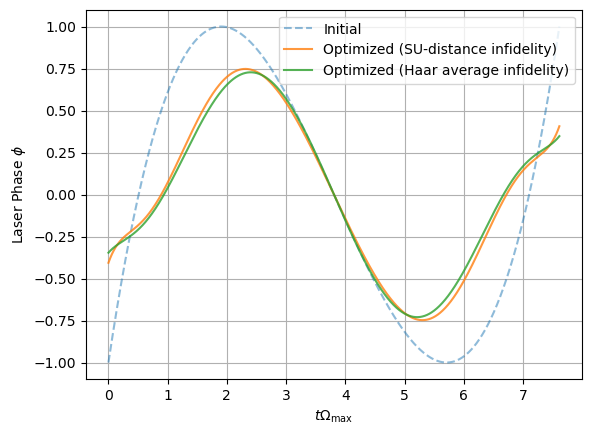

In [5]:
# ignore the derivative returned by the fidelity function
su_unoptimized_infidelity, _ = goat_optimizer.evaluate_function(SUDistanceInfidelity(), eval_params=params_0, target_unitary=target_unitary)
su_optimized_infidelity, _ = goat_optimizer.evaluate_function(SUDistanceInfidelity(), eval_params=su_infidelity_params, target_unitary=target_unitary)
haar_unoptimized_infidelity, _ = goat_optimizer.evaluate_function(HaarAverageInfidelity(), eval_params=params_0, target_unitary=target_unitary)
haar_optimized_infidelity, _ = goat_optimizer.evaluate_function(HaarAverageInfidelity(), eval_params=haar_infidelity_params, target_unitary=target_unitary)

print(f"SU-distance unoptimized infidelity = {su_unoptimized_infidelity}")
print(f"SU-distance infidelity = {su_optimized_infidelity}")
print(f"Haar average unoptimized infidelity = {haar_unoptimized_infidelity}")
print(f"Haar average infidelity = {haar_optimized_infidelity}")

# plot the optimized gates
ts = np.linspace(0, t_max, 10001)
plt.xlabel("$t\\Omega_{\\text{max}}$")
plt.ylabel("Laser Phase $\\phi$")
plt.plot(ts, chebyshev.chebval((2/t_max)*ts-1, params_0[:-1]), linestyle="--", alpha=0.5, label="Initial")
plt.plot(ts, chebyshev.chebval((2/t_max)*ts-1, su_infidelity_params[:-1]), alpha=0.8, label="Optimized (SU-distance infidelity)")
plt.plot(ts, chebyshev.chebval((2/t_max)*ts-1, haar_infidelity_params[:-1]), alpha=0.8, label="Optimized (Haar average infidelity)")
plt.grid()
plt.legend()

plt.show()

Here is a quick summary of the above section on how to use ``goat_qoc`` to optimize gates.
1. Identify the control segments and parameters used to describe the gate, and construct a ``GOATOptimizer`` object. If ``AnalogControlSegment``s are used, define control Hamiltonians and their coefficients.
2. Run the optimization by choosing a cost function and calling ``GOATOptimizer.run_optimization``.
3. Anaylze the optimzed gate and/or evaluate functions based on the optimization result by calling ``GOATOptimizer.evaluate_function``.

### Sweep Gate Time

This section contains an example of sweeping the Rydberg gate time to determine the shortest possible high-fidelity gate (replicating the results of Ref [2]). It does not contain any new concepts, but rather serves as an additional example of how to use ``goat_qoc`` in a practial setting. At a high-level, the code involves creating new control coeffiecients and a new ``GOATOptimizer`` object for each gate time being swept and running a seperate optimization for each gate time.

In [6]:
n_times = 14*5+1 # number of gate time to sweep between the range T = [1, 15]
gate_times = np.linspace(1, 15, n_times)
goat_optimizers = [] # where the optimizaton results will be stored
fidelities = np.zeros(n_times) # where the optimizer fidelities will be stored

cheb_trunc = 10 # number of terms in the chebshev series for controls
params_0 = np.zeros(cheb_trunc + 1)
params_0[3] = 1

# function to create control coefficients for each gate time
def create_chebyshev_controls(t_span):
    t_max = t_span[1]

    def controls(t, params):
        phase = chebyshev.chebval( (2/t_max)*t-1, params)
        return np.array([np.exp(1j * phase), np.exp(-1j * phase)])

    def dcontrols(t, params):
        phase = chebyshev.chebval((2/t_max)*t-1, params);
        plus_exp_val = 1j * np.exp(1j * phase)
        minus_exp_val = -1j * np.exp(-1j * phase)

        deriv_matrix = np.zeros((2, cheb_trunc), dtype=complex)
        for i in range(cheb_trunc):
            c = np.zeros(cheb_trunc)
            c[i] = 1
            deriv_matrix[0][i] = plus_exp_val * chebyshev.chebval((2/t_max)*t-1, c)
            deriv_matrix[1][i] = minus_exp_val * chebyshev.chebval((2/t_max)*t-1, c)
        return deriv_matrix

    return controls, dcontrols

optimizer_opts = {"maxiter": 200, "disp": False, "ftol": 1e-15, "gtol": 1e-15} # for L-BFGS-B

In [7]:
# optimize gate for each gate time
for i in range(n_times):
    t_span = [0, gate_times[i]]
    c, dc = create_chebyshev_controls(t_span)

    control_segments = [
        AnalogControlSegment(cheb_trunc, H_0, H_controls, c, dc, t_span,
                             U_truncator=U_truncator),
        SingleQubitPhaseSegment([1, 2])
    ]

    goat_optimizer = GOATOptimizer(2, control_segments)
    goat_optimizer.run_optimization(params_0, target_unitary, HaarAverageInfidelity(), optimizer_opts=optimizer_opts)

    fidelities[i] = goat_optimizer.optimization_result.fun
    goat_optimizers.append(goat_optimizer)

    print(f"Gate time: {gate_times[i]}, Infidelity: {fidelities[i]}")

Gate time: 1.0, Infidelity: 0.39986284494874225
Gate time: 1.2, Infidelity: 0.3997162784041889
Gate time: 1.4, Infidelity: 0.3994758588353262
Gate time: 1.6, Infidelity: 0.39910875001476953
Gate time: 1.8, Infidelity: 0.39960170547470464
Gate time: 2.0, Infidelity: 0.3993486483352491
Gate time: 2.2, Infidelity: 0.396853166993655
Gate time: 2.4000000000000004, Infidelity: 0.3955649646690804
Gate time: 2.6, Infidelity: 0.3939236157415318
Gate time: 2.8, Infidelity: 0.3918732087222885
Gate time: 3.0, Infidelity: 0.3893549429313199
Gate time: 3.2, Infidelity: 0.38630740485046244
Gate time: 3.4000000000000004, Infidelity: 0.38645686400876345
Gate time: 3.6, Infidelity: 0.3397715646438153
Gate time: 3.8000000000000003, Infidelity: 0.373341371708684
Gate time: 4.0, Infidelity: 0.3120185962325248
Gate time: 4.2, Infidelity: 0.36083110837194377
Gate time: 4.4, Infidelity: 0.36343551984102174
Gate time: 4.6, Infidelity: 0.35668826949726495
Gate time: 4.800000000000001, Infidelity: 0.400093747630

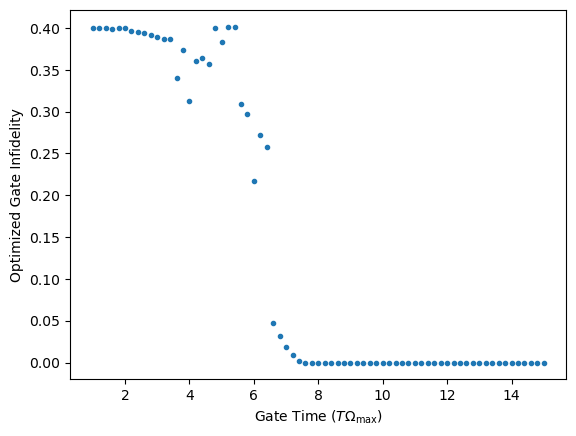

In [8]:
# Plot optimized gate fidelity as a function of gate time
plt.plot(gate_times, fidelities, marker=".", linestyle="")
plt.xlabel("Gate Time ($T\\Omega_{\\text{max}}$)")
plt.ylabel("Optimized Gate Infidelity")
plt.show()

The plot above roughly agrees with Figure 1b of Ref. [2] and confirms that GOAT converges on the correct optimal gate time of $T\Omega_{\text{max}}\approx 7.612$ even when using a truncated Chebyshev series parameterization of the phase.

## Calculating the Hessian of Gate Fidelity (Computing Higher-Order Derivatives)

One of the unique advantages of GOAT over other quantum optimal control algorithms is that it offers a natural way to compute higher-order derivatives of gate fidelity with respect to control parameters. Computing these higher order derivatives of fidelity requires computing higher-order derivatives of the unitaries in each control segment.

From a user's perspective, the only additional requirement to use ``goat_qoc`` to compute higher-order derivatives of fidelity is to change the definition of the control segments appropriately. For example, in an ``AnalogControlSegment``, the ODE governing the evolution of the second-order derivatives of fidelity are,
$$\partial_t\left(\partial^2_{\alpha\beta}U\right)=-\frac{i}{\hbar}\left(\partial^2_{\alpha\beta}H\cdot U + \partial_{\alpha}H\cdot\partial_{\beta}U + \partial_{\beta}H\cdot\partial_{\alpha}U + H\cdot\partial^2_{\alpha\beta}U\right)$$
which requires the user to provide second-order derivatives of the control coeffiecients. These are,
$$\partial^2_{\alpha_i\alpha_j}c_{\pm}(\overline{\alpha},t)=-f_i(\tau)\cdot f_j(\tau)\cdot\Omega_{\text{max}}e^{\pm i\sum_{k=0}^N\alpha_k f_k(\tau)}$$
The following cell defines the second-order derivatives of the control coefficients, creates a new ``GOATOptimizer`` object, and re-optimizes the gate to prepare for the Hessian calculation.

In [6]:
# define controls
cheb_trunc = 10 
t_min = 0
t_max = 7.612 
t_span = [t_min, t_max]

def d2chebyshev_controls(t, params):
    cheb_t = (2/t_max)*t-1
    eye = np.eye(params.size)

    control_hessians = np.zeros((2, params.size, params.size), dtype=complex)
    phase = chebyshev.chebval(cheb_t, params)
    plus_exp_val = np.exp(1j * phase)
    minus_exp_val = np.exp(-1j * phase)

    for i in range(params.size):
        for j in range(params.size):
            fi = chebyshev.chebval(cheb_t, eye[i])
            fj = chebyshev.chebval(cheb_t, eye[j])
            control_hessians[0][i][j] = -plus_exp_val * fi * fj
            control_hessians[1][i][j] = -minus_exp_val * fi * fj
    
    return control_hessians

# define control segments and initialize GOATOptimizer
control_segments = [
    AnalogControlSegment(cheb_trunc, 
                         H_0, 
                         H_controls, 
                         chebyshev_controls, 
                         dchebyshev_controls, 
                         t_span,
                         U_truncator=U_truncator,
                         d2controls=d2chebyshev_controls),
    SingleQubitPhaseSegment([1, 2])
]

goat_optimizer = GOATOptimizer(2, control_segments)

# set initial conditions and run optimization
params_0 = np.zeros(cheb_trunc + 1)
params_0[3] = 1

goat_optimizer.run_optimization(params_0, target_unitary, HaarAverageInfidelity())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.92804D-01    |proj g|=  2.60703D-01

At iterate    1    f=  4.15583D-01    |proj g|=  5.59855D-01

At iterate    2    f=  2.93590D-01    |proj g|=  7.16224D-01

At iterate    3    f=  1.76402D-01    |proj g|=  2.48107D-01


 This problem is unconstrained.



At iterate    4    f=  1.37998D-01    |proj g|=  1.81341D-01

At iterate    5    f=  1.14532D-01    |proj g|=  1.47392D-01

At iterate    6    f=  7.30501D-02    |proj g|=  6.50486D-01

At iterate    7    f=  3.26636D-02    |proj g|=  1.13544D-01

At iterate    8    f=  1.73879D-02    |proj g|=  6.23985D-02

At iterate    9    f=  1.64385D-03    |proj g|=  3.98391D-02

At iterate   10    f=  1.04008D-03    |proj g|=  5.66597D-02

At iterate   11    f=  2.03495D-04    |proj g|=  1.29402D-02

At iterate   12    f=  1.33275D-04    |proj g|=  3.18884D-03

At iterate   13    f=  8.69598D-05    |proj g|=  3.09488D-03

At iterate   14    f=  3.47725D-05    |proj g|=  1.22555D-03

At iterate   15    f=  1.81181D-05    |proj g|=  5.82057D-04

At iterate   16    f=  1.30600D-05    |proj g|=  3.15400D-03

At iterate   17    f=  9.37101D-06    |proj g|=  1.97510D-03

At iterate   18    f=  8.33747D-06    |proj g|=  2.75752D-04

At iterate   19    f=  8.22006D-06    |proj g|=  1.90928D-04

At iter

Now, to compute the fidelity Hessian around the optimized gate parameters, the ``GOATOptimizer.evaluate_function`` function can be called. This function allows the user to evaluate any function that depends on the gate unitary and its derivatives. To calculate the fidelity hessian, the ``HaarAverageInfidelityHessian`` can be passed to ``evaluate_function``. ``HaarAverageInfideltiyHessian`` contains metadata that automatically informs the ``GOATOptimizer`` to compute second-order derivatives of the gate unitary. Also, unless otherwise specified, the ``GOATOptimizer`` will use the optimized gate parameters from the last call to ``run_optimization`` when computing the gate unitary and its derivatives. The following cell demonstrates how to compute the hessian of the gate fidelity.

As a quick aside on how computing higher-order gate unitary derivatives works behind the scenes, note that there are two classes of second-order derivatives. The first is where both parameters are in the same control segment, and the second is where the two parameters are in different control segments. For example, if the ``GOATOptimizer`` contains two control segments, so the gate unitary is $U=U_1U_2$, then the two types of second derivatives can look like $\partial^2_{\alpha\beta}U=\partial^2_{\alpha\beta}U_1\cdot U_2$ or $\partial^2{\alpha\beta}U=\partial_{\alpha}U_1\cdot\partial_{\beta}U_2$. In the latter case, second-order derivatives of the gate unitary are not actually used. ``goat_qoc`` automatically handles the classification of second-order derivatives based on their parameter indices so the user does not have to think about this implementation detail, but it is useful to be aware of nonetheless.

In [ ]:
from goat_functions import HaarAverageInfidelityHessian

infidelity_hessian = goat_optimizer.evaluate_function(HaarAverageInfidelityHessian(), target_unitary=target_unitary)

Some additional analysis of the fidelity hessian is not only intersting, but also helps illustrate some additional features of the ``GOATOptimizer.evaluate_function`` function. First, we can compute the eigenvalues of the fidelity hessian matrix. Doing so reveals that only six of the Hessian eigenvalues are meaningfully nonzero, which suggests that there is degenerate subspace of directions in parameter space to which the gate fidelity is insensitive.

Hessian Eigenavalues = [-7.78369191e+00 -5.10962672e+00 -1.50114209e+00 -6.89282448e-01
 -1.51617558e-01 -5.86550607e-04 -1.44300985e-07 -8.82019556e-08
 -3.13497107e-08 -1.96550736e-10 -1.55800462e-16]


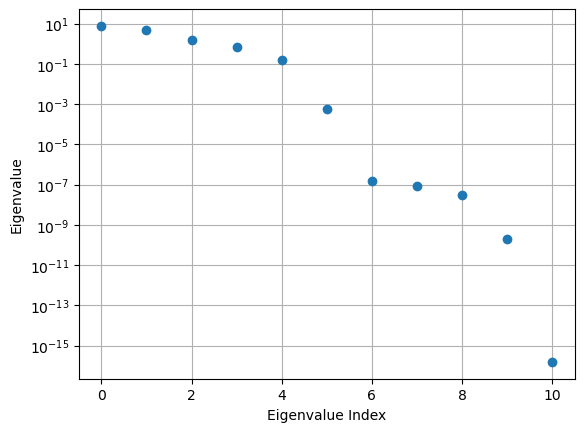

In [27]:
# compute eigenvalues and eigenvectors of hessian matrix
evals, evecs = np.linalg.eigh(-infidelity_hessian) # fidelity_hessian = -infidelity_hessian
print(f"Hessian Eigenavalues = {evals}")
plt.semilogy(-evals, marker="o", linestyle="") # negate the eigenvalues to plot on a log plot
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.grid()

To verify that the gate fidelity is insensitive to changes in parameter space corresponding to the zero-eigenvalue eigenvectors of the fideltiy hessian, we can evaluate the gate fidelity around the optimal point in parameter space, moving short distances along each eigenvector. The gate fidelity can once again be evaluted using ``evaluate_function``, but this time, we can evaluate the fidelity at different points in parameter space by passing a value to the ``eval_params`` parameter. The following two cells show how to calculate and plot the fidelity sensitivity to different directions in parameter space.

In [9]:
# sensitivity to errors
n_evec_pts = 21
evec_strength = np.linspace(-0.1, 0.1, n_evec_pts)
evec_infidelity = np.zeros((evecs.shape[1], n_evec_pts))

params_opt = goat_optimizer.optimization_result.x

for evec_i in range(evecs.shape[1]):
    for i in range(n_evec_pts):
        params_evec = params_opt + evec_strength[i] * evecs[:, evec_i]
        evec_infidelity[evec_i][i] = goat_optimizer.evaluate_function(HaarAverageInfidelity(), eval_params=params_evec, target_unitary=target_unitary)[0]

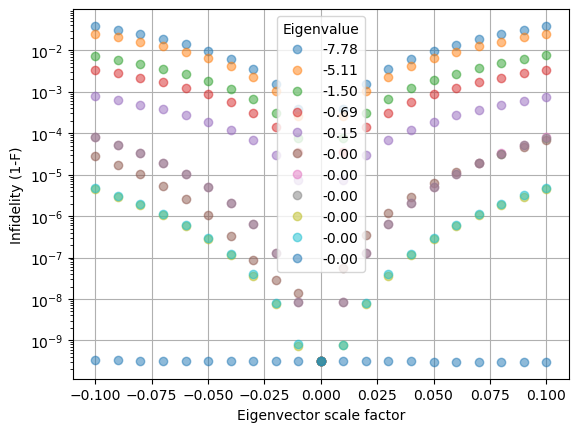

In [10]:
for evec_i in range(evecs.shape[1]): 
    plt.semilogy(evec_strength, evec_infidelity[evec_i], marker="o", linestyle="", alpha=0.5, label=f"{evals[evec_i]:.2f}")

plt.xlabel("Eigenvector scale factor")
plt.ylabel("Infidelity (1-F)")
plt.legend(title="Eigenvalue")
plt.grid()
plt.show()

The plot above verifies that the gate fidelity is only sensitive to a changes in a few directions in parameter space.

As a final example, by seperating the computation of the gate *unitary* and its derivatives from the computation of gate *fidelity* and its derivatives, ``goat_qoc`` allows one to compute the senstivity of gate fidelity to parameters that are not being optimized over. For example, it was assumed when formulating the Rydberg gate Hamiltonian that the drive amplitude is kept constant throughout the gate, but in practice, laser intensity fluctuations make this assumption invalid. Thus, one may be interested in calculating the sensitivity of gate fidelity to drive amplitude without necessarily including drive ampltude as an optimization parameter. Doing this once again requires redefining the control segments with the appropriate parameters. In particular, the control Hamiltonians in the ``AnalogControlSegment`` remain the same, but their coefficients now become $c_{\pm}(\epsilon,\overline{\alpha},t)=(1+\epsilon)\Omega_{\text{max}}e^{\pm i\phi(\overline{\alpha},t)}$, where $\epsilon$ is an additional parameter capturing variation in drive amplitude. The following cell shows how to define new control coefficients with the additional amplitude parameter and create a ``GOATOptimizer`` object.

In [16]:
# compute hessian w.r.t. gate amplitude
cheb_trunc = 10
t_min = 0
t_max = 7.612
t_span = [t_min, t_max]

def chebyshev_controls_with_drive(t, params):
    eps_drive = params[0]
    controls = params[1:]
    chebval = chebyshev.chebval( (2/t_max)*t-1, controls)
    return np.array([
        (1 + eps_drive) * np.exp( 1j * chebval),
        (1 + eps_drive) * np.exp( -1j * chebval) 
    ])

def dchebyshev_controls_with_drive(t, params):
    eps_drive = params[0]
    controls = params[1:]
    cheb_t = (2/t_max)*t-1

    deriv_matrix = np.zeros((2, params.size), dtype=complex)
    phase = chebyshev.chebval(cheb_t, controls)
    plus_exp_val = 1j * (1 + eps_drive) * np.exp(1j * phase)
    minus_exp_val = -1j * (1 + eps_drive) * np.exp(-1j * phase)

    for i in range(1, params.size):
        c = np.zeros(controls.size)
        c[i-1] = 1
        deriv_matrix[0][i] = plus_exp_val * chebyshev.chebval(cheb_t, c)
        deriv_matrix[1][i] = minus_exp_val * chebyshev.chebval(cheb_t, c)
    deriv_matrix[0][0] = np.exp(1j * phase) 
    deriv_matrix[1][0] = np.exp(-1j * phase)

    return deriv_matrix

def d2chebyshev_controls_with_drive(t, params):
    eps_drive = params[0]
    controls = params[1:]

    cheb_t = (2/t_max)*t-1
    eye = np.eye(controls.size)

    control_hessians = np.zeros((2, params.size, params.size), dtype=complex)
    phase = chebyshev.chebval(cheb_t, controls)

    plus_exp_val = (1 + eps_drive) * np.exp(1j * phase)
    minus_exp_val = (1 + eps_drive) * np.exp(-1j * phase)

    for i in range(1, params.size):
        for j in range(1, params.size):
            fi = chebyshev.chebval(cheb_t, eye[i-1])
            fj = chebyshev.chebval(cheb_t, eye[j-1])
            control_hessians[0][i][j] = -plus_exp_val * fi * fj
            control_hessians[1][i][j] = -minus_exp_val * fi * fj

        control_hessians[0][i][0] = 1j * fi * np.exp(1j * phase)
        control_hessians[0][0][i] = control_hessians[0][i][0]  
        control_hessians[1][i][0] = -1j * fi * np.exp(-1j * phase)
        control_hessians[1][0][i] = control_hessians[1][i][0]  
    
    return control_hessians

control_segments_with_drive = [
    AnalogControlSegment(cheb_trunc+1, H_0, H_controls, 
                         chebyshev_controls_with_drive, 
                         dchebyshev_controls_with_drive, t_span,
                         U_truncator=U_truncator, d2controls=d2chebyshev_controls_with_drive),
    SingleQubitPhaseSegment([1, 2])
]

goat_optimizer_with_drive = GOATOptimizer(2, control_segments_with_drive)

Now, we can once again compute the fidelity, its gradient, and its hessian with the new ``GOATOptimizer``, but we start with the parameters of the *previously optimized* gate and append drive amplitude term to the parameter list. The following cell demonstrates this computation.

In [29]:
params = np.concatenate(([0], goat_optimizer.optimization_result.x))

fidelity_with_drive, grad_with_drive = goat_optimizer_with_drive.evaluate_function(HaarAverageInfidelity(), eval_params=params, target_unitary=target_unitary)
hessian_with_drive = goat_optimizer_with_drive.evaluate_function(HaarAverageInfidelityHessian(), eval_params=params, target_unitary=target_unitary)

We can see that the gate fidelity is unchanged, but now the fidelity gradient contains information about sensitivity to changes in drive amplitude. Diagonlizing the Hessian also reveals that though the eigenvalues in the presence of a drive paramter have changed, the number of directions in parameter space to which the fidelity is sensitive is still six.

Gate Infdielity = 3.272366821960304e-10
d(Infidelity)/dε = -1.4755698781990905e-07
Hessian Eigenvalues = [-9.62757029e+00 -7.02098068e+00 -5.10962567e+00 -1.15013289e+00
 -6.89282229e-01 -1.46509269e-01 -1.58878836e-07 -1.41814196e-07
 -4.78911682e-08 -2.97156924e-08 -1.69628668e-10  4.19340391e-16]


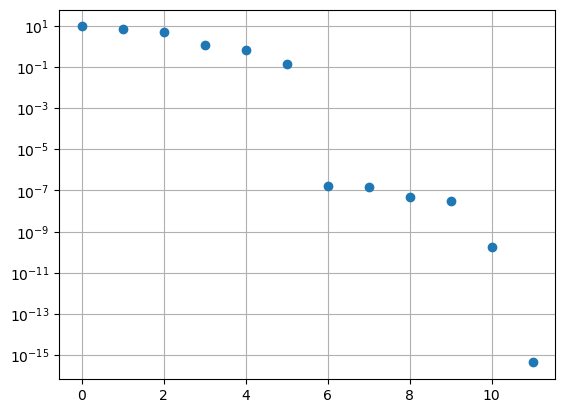

In [26]:
print(f"Gate Infdielity = {fidelity_with_drive}")
print(f"d(Infidelity)/dε = {grad_with_drive[0]}")
# compute eigenvalues and eigenvectors of hessian matrix
evals, evecs = np.linalg.eigh(-hessian_with_drive)
print(f"Hessian Eigenvalues = {evals}")
# plt.plot(evals, marker="o", linestyle="")
plt.semilogy(np.abs(evals), marker="o", linestyle="")
plt.grid()

## Robustness (Using Different Cost Functions)

Another advantage of GOAT is that the optimizer's cost function can defined flexibily. As long as there is a way to compute the cost function and its gradient from the gate unitary and its derivatives, it is compatible with the GOAT algorithm. As an example, this section describes how to optimize Rydberg gates that robust to fluctuations in drive amplitude. Using the same language as the amplitude-parameterized gates in the previous section, the cost function can be written as,
$$\text{Cost}(\epsilon,\overline{\alpha})=1-\mathcal{F(\overline{\alpha})}+\lambda\frac{\partial^2\mathcal{F}}{\partial\epsilon^2}.$$
where $\lambda$ is a hyperparameter that tunes the relative strength between the fidelity cost and robustness cost. Note that the derivative of this cost function is,
$$\frac{\partial\text{Cost}}{\partial\overline{\alpha}}=-\frac{\partial\mathcal{F}}{\partial\overline{\alpha}}+\frac{\partial^3\mathcal{F}}{\partial\epsilon^2\partial\overline{\alpha}},$$
which depends on *third-order derivatives* of the gate fidelity w.r.t control parameters and consequently third derivatives of the gate unitary. Just like for second-order derivatives, the ``AnalogcControlSegment`` can be easily extended to support computation of third-order derivatives of the gate unitary, where the relevant ODE is,
$$\partial_t\left(\partial^3_{\alpha\beta\gamma}U\right)=-\frac{i}{\hbar}\left(\partial^3_{\alpha\beta\gamma}H\cdot U + \partial^2_{\alpha\beta}H\cdot\partial_{\gamma}U + \partial^2_{\alpha\gamma}H\cdot\partial_{\beta}U + \partial^2_{\beta\gamma}H\cdot\partial_{\alpha}U + \partial_{\alpha}H\cdot\partial^2_{\beta\gamma}U + \partial_{\beta}H\cdot\partial^2_{\alpha\gamma}U + \partial_{\gamma}H\cdot\partial^2_{\alpha\beta}U + H\cdot\partial^3_{\alpha\beta\gamma}U\right).$$
Once again, from a user's perspective, the only requirement to use ``goat_qoc`` to optimize a different cost function that may depend on third-order derivatives of fidelity is to define the control segments and cost function appropriately. The control coefficients for the ``AnalogControlSegment`` are the same as those defined when including drive amplitude in the fidelity Hessian above. Namely, $c_{\pm}(\epsilon,\overline{\alpha},t)=(1+\epsilon)\Omega_{\text{max}}e^{\pm i\phi(\overline{\alpha},t)}$. Now, however, third-order derivatives of $c_\pm$ w.r.t. the control parameters are required to compute third-order derivatives of the gate unitary. The following cell defines the control coefficients and instantiates a ``GOATOptimizer`` object for amplitude-robust gates.

In [ ]:
t_min = 0
t_max = 14.31 # empirically determined optimal gate time for robust gates from Ref [3]
t_span = [t_min, t_max]
cheb_trunc = 20

def chebyshev_controls_with_drive(t, params):
    eps_drive = params[0]
    controls = params[1:]
    chebval = chebyshev.chebval( (2/t_max)*t-1, controls)
    return np.array([
        (1 + eps_drive) * np.exp( 1j * chebval),
        (1 + eps_drive) * np.exp( -1j * chebval) 
    ])

def dchebyshev_controls_with_drive(t, params):
    eps_drive = params[0]
    controls = params[1:]
    cheb_t = (2/t_max)*t-1

    deriv_matrix = np.zeros((2, params.size), dtype=complex)
    phase = chebyshev.chebval(cheb_t, controls)
    plus_exp_val = 1j * (1 + eps_drive) * np.exp(1j * phase)
    minus_exp_val = -1j * (1 + eps_drive) * np.exp(-1j * phase)

    for i in range(1, params.size):
        c = np.zeros(controls.size)
        c[i-1] = 1
        deriv_matrix[0][i] = plus_exp_val * chebyshev.chebval(cheb_t, c)
        deriv_matrix[1][i] = minus_exp_val * chebyshev.chebval(cheb_t, c)
    deriv_matrix[0][0] = np.exp(1j * phase) 
    deriv_matrix[1][0] = np.exp(-1j * phase)

    return deriv_matrix

def d2chebyshev_controls_with_drive(t, params):
    eps_drive = params[0]
    controls = params[1:]

    cheb_t = (2/t_max)*t-1
    eye = np.eye(controls.size)

    control_hessians = np.zeros((2, params.size, params.size), dtype=complex)
    phase = chebyshev.chebval(cheb_t, controls)

    plus_exp_val = (1 + eps_drive) * np.exp(1j * phase)
    minus_exp_val = (1 + eps_drive) * np.exp(-1j * phase)

    for i in range(1, params.size):
        fi = chebyshev.chebval(cheb_t, eye[i-1])
        for j in range(1, params.size):
            fj = chebyshev.chebval(cheb_t, eye[j-1])
            control_hessians[0][i][j] = -plus_exp_val * fi * fj
            control_hessians[1][i][j] = -minus_exp_val * fi * fj

        control_hessians[0][i][0] = 1j * fi * np.exp(1j * phase)
        control_hessians[0][0][i] = control_hessians[0][i][0]  
        control_hessians[1][i][0] = -1j * fi * np.exp(-1j * phase)
        control_hessians[1][0][i] = control_hessians[1][i][0]  
    
    return control_hessians

def d3chebyshev_controls_with_drive(t, params):
    eps_drive = params[0]
    controls = params[1:]

    cheb_t = (2/t_max)*t-1
    eye = np.eye(controls.size)

    control_third_orders = np.zeros((2, params.size, params.size, params.size), dtype=complex)
    phase = chebyshev.chebval(cheb_t, controls)

    plus_exp_val = (1 + eps_drive) * np.exp(1j * phase)
    minus_exp_val = (1 + eps_drive) * np.exp(-1j * phase)

    for i in range(1, params.size):
        fi = chebyshev.chebval(cheb_t, eye[i-1])
        for j in range(1, params.size):
            fj = chebyshev.chebval(cheb_t, eye[j-1])
            for k in range(1, params.size):
                fk = chebyshev.chebval(cheb_t, eye[k-1])
                control_third_orders[0][i][j][k] = -1j * plus_exp_val * fi * fj * fk
                control_third_orders[1][i][j][k] = -1j * minus_exp_val * fi * fj * fk
            
            control_third_orders[0][i][j][0] = -np.exp(1j * phase) * fi * fj
            control_third_orders[0][j][i][0] = control_third_orders[0][i][j][0]
            control_third_orders[0][0][i][j] = control_third_orders[0][i][j][0]
            control_third_orders[0][0][j][i] = control_third_orders[0][i][j][0]
            control_third_orders[0][i][0][j] = control_third_orders[0][i][j][0]
            control_third_orders[0][j][0][i] = control_third_orders[0][i][j][0]

            control_third_orders[1][i][j][0] = -np.exp(-1j * phase) * fi * fj
            control_third_orders[1][j][i][0] = control_third_orders[1][i][j][0]
            control_third_orders[1][0][i][j] = control_third_orders[1][i][j][0]
            control_third_orders[1][0][j][i] = control_third_orders[1][i][j][0]
            control_third_orders[1][i][0][j] = control_third_orders[1][i][j][0]
            control_third_orders[1][j][0][i] = control_third_orders[1][i][j][0]

    return control_third_orders

control_segments = [
    AnalogControlSegment(1 + cheb_trunc, H_0, H_controls,
                         chebyshev_controls_with_drive,
                         dchebyshev_controls_with_drive,
                         t_span,
                         d2controls=d2chebyshev_controls_with_drive,
                         d3controls=d3chebyshev_controls_with_drive,
                         U_truncator=U_truncator),
    SingleQubitPhaseSegment([1, 2])
]

goat_optimizer = GOATOptimizer(2, control_segments)

Since $\lambda$ is a property of the cost function, it is passed as a parameter to the ``HaarInfidelityAndRobustness`` constructor when calling ``run_optimization``. The following cell optimizes gates for $\lambda=0$ (optimizing for just fidelity) and $\lambda=10^{-5}$. Note that the robustness term in the cost function makes the cost landscape more complex, so the optimizer can take a long time to terminate. Thus, we provide the results of running the cell below in a ``robust_gate_results.pkl``, which can be loaded two cells down.

In [49]:
from goat_functions import HaarInfidelityAndRobustness

robustness_lambdas = [0, 1e-5] # , 1e-3] # , 1e-4, 1e-6]
opt_results = []

params_0 = np.zeros(1 + cheb_trunc + 1)
params_0[4] = 1

for l in robustness_lambdas:
    print(f"Optimizing λ={l}")
    goat_optimizer.run_optimization(params_0, target_unitary, HaarInfidelityAndRobustness(robustness_lambda=l))
    opt_results.append(goat_optimizer.optimization_result)

Optimizing λ=0


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           22     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.36224D-01    |proj g|=  1.06493D+00

At iterate    1    f=  1.22492D-01    |proj g|=  2.40006D-01

At iterate    2    f=  1.15013D-01    |proj g|=  1.62444D-01

At iterate    3    f=  1.10198D-01    |proj g|=  1.56117D-01

At iterate    4    f=  7.87330D-02    |proj g|=  1.86002D-01

At iterate    5    f=  6.61800D-02    |proj g|=  1.54310D-01

At iterate    6    f=  2.69512D-02    |proj g|=  3.21953D-01

At iterate    7    f=  1.56930D-02    |proj g|=  1.48062D-01

At iterate    8    f=  6.76833D-03    |proj g|=  5.03184D-02

At iterate    9    f=  3.09956D-03    |proj g|=  2.73380D-02

At iterate   10    f=  7.44675D-04    |proj g|=  4.02492D-02

At iterate   11    f=  1.25210D-04    |proj g|=  3.06566D-02

At iterate   12    f=  6.91531D-06    |proj g|=  8.45495D-03

At iterate   13    f=  1.2

 This problem is unconstrained.



At iterate    1    f=  1.22641D-01    |proj g|=  2.39888D-01

At iterate    2    f=  1.15170D-01    |proj g|=  1.62390D-01

At iterate    3    f=  1.10359D-01    |proj g|=  1.56067D-01

At iterate    4    f=  7.89437D-02    |proj g|=  1.85638D-01

At iterate    5    f=  6.63963D-02    |proj g|=  1.54605D-01

At iterate    6    f=  2.71793D-02    |proj g|=  3.20330D-01

At iterate    7    f=  1.59005D-02    |proj g|=  1.47896D-01

At iterate    8    f=  7.01260D-03    |proj g|=  5.03482D-02

At iterate    9    f=  3.38135D-03    |proj g|=  2.70414D-02

At iterate   10    f=  1.10096D-03    |proj g|=  3.97753D-02

At iterate   11    f=  5.14106D-04    |proj g|=  3.03560D-02

At iterate   12    f=  4.06017D-04    |proj g|=  7.66668D-03

At iterate   13    f=  4.00831D-04    |proj g|=  3.72449D-03

At iterate   14    f=  4.00017D-04    |proj g|=  3.68424D-04

At iterate   15    f=  3.99982D-04    |proj g|=  2.53859D-04

At iterate   16    f=  3.99551D-04    |proj g|=  5.66543D-04

At iter

In [58]:
# optional cell for storing/loading parameters for robust gates
import pickle

# save optimization results

# with open("robust_gate_results.pkl", "wb") as f:
#     pickle.dump( { "robustness_lambdas": robustness_lambdas, "opt_results": opt_results, }, f)

# load optimization results

with open("robust_gate_results.pkl", "rb") as f:
    data = pickle.load(f)
robustness_lambdas = data["robustness_lambdas"]
opt_results = data["opt_results"]

Now, the robustness of the optimized gates to deviations in drive amplitudes can be assessed by sweeping $\epsilon$ around $0$ and evaluating the gates' fidelities. The following cell plots the sensitivity of both gates to drive amplitude deviations as well as their pulse shapes.

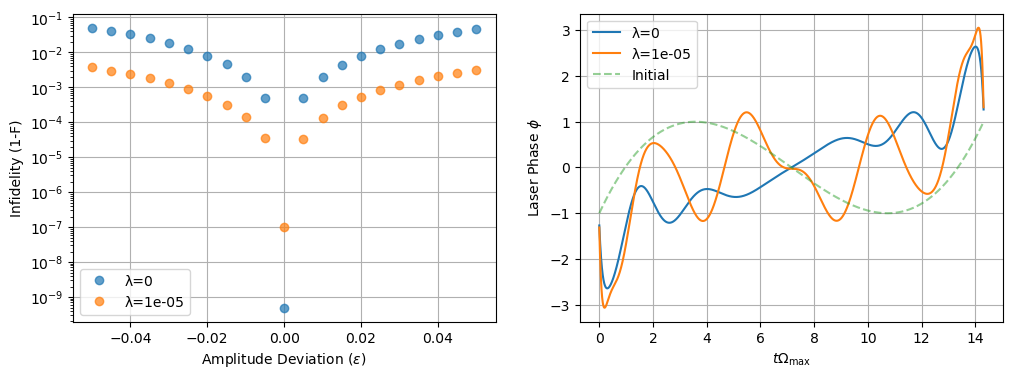

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ts = np.linspace(0, t_max, 10001)

# sweep drive amplitude and evaluate fidelity
npts = 21
n_lambdas = len(robustness_lambdas)
amplitude_deviations = np.linspace(-0.05, 0.05, npts)
amplitude_fidelities = np.zeros((n_lambdas, npts)) 

for k in range(n_lambdas):
    for i in range(npts):
        params = opt_results[k].x
        params[0] = amplitude_deviations[i]
        amplitude_fidelities[k][i] = goat_optimizer.evaluate_function(HaarAverageInfidelity(), eval_params=params, target_unitary=target_unitary)[0]
    ax1.semilogy(amplitude_deviations, amplitude_fidelities[k], marker="o", linestyle="", alpha=0.7, label=f"λ={robustness_lambdas[k]}")
ax1.set_xlabel("Amplitude Deviation ($\\epsilon$)")
ax1.set_ylabel("Infidelity (1-F)")
ax1.grid()
ax1.legend()

# plot pulse shapes
for k in range(len(robustness_lambdas)):
    ax2.plot(ts, chebyshev.chebval((2/t_max)*ts-1, opt_results[k].x[1:-1]), label=f"λ={robustness_lambdas[k]}") # label=f"$\\lambda={lambda_strs[k]}$")
ax2.plot(ts, chebyshev.chebval((2/t_max)*ts-1, params_0[1:-1]), linestyle="--", alpha=0.5, label="Initial")

ax2.set_xlabel("$t\\Omega_{\\text{max}}$")
ax2.set_ylabel("Laser Phase $\\phi$")
ax2.legend()
ax2.grid()

plt.show()

The amplitude sensitivity plot shows that including amplitude-robustness in the cost function indeed makes the final gate more robust to deviations in drive amplitude, but this comes at the cost of lower gate fidelity. This reveals a trade-off between a gate pulse's accuracy and its robustness. In practice $\lambda$ should tuned based on the priorities of experimenters.

Note that, as mentioned before, adding the robustness terms makes the cost function more complex, so the optimizer may take a long time to converge, or it may converge to a local minimum solution. Indeed, Ref [3] describes gates that are more robust than the gates shown above. Importantly, however, these numerical issues are a property of the specific problem of optimizing robust gates rather than the GOAT implementation, and the purpose of including robustness in this notebook is to serve as an example of how the ``goat_qoc`` can be used to optimize for cost functions that involve higher-order derivatives of gate fideltiy.

## Bandwidth Cost (More on Using Different Cost Functions)

The last example in this notebook is another example of using GOAT with a custom cost function, but this time, the cost function depends on the *control parameters*. The goal is to generate gates that are limited in frequency bandwidth, so that the applied pulse modulation is compatible with the bandwidth of the acousto-optic modulators that shape the pulse. To do so, it is useful to express the gate in a basis of *Slepian* functions, which are localized in both the time and frequency domains. Importantly, higher-order Slepians are more complex, but are less localized in the frequency domain, which is the property that will be used to impose a cost on pulse bandwidth. The Slepian functions are constructed below and plotted in both the time and frequency domains.

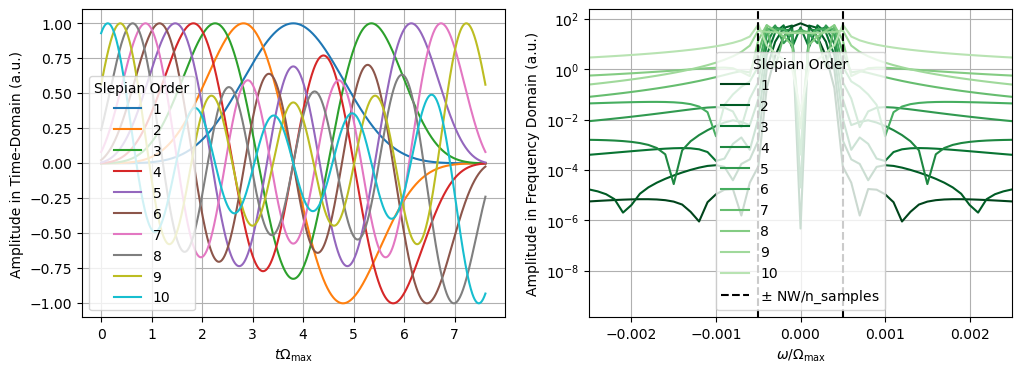

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import dpss

t_min = 0
t_max = 7.612
t_span = [t_min, t_max]

n_sleps = 10 # number of Slepian functions to use
n_samples = 10001 # number of samples to take between [0, 1] of the Slepian function for interpolation
NW = 5 # parameter controlling the degree of localization in the frequency domain of the Slepian function (higher NW -> more localized)

# construct functions that give the value of each Slepian function at arbitary time by interpolating from n_samples samples.
def slepians_rescaled(n, T, NW, n_samples=10001):
    sampled_slepians = dpss(n_samples, NW, Kmax=n + 1, sym=False)
    for i in range(n):
        sampled_slepians[i] /= np.max(sampled_slepians[i])

    t_grid = np.linspace(0, T, n_samples)
    return [
        lambda t, sampled_slep=sampled_slep: np.interp(t, t_grid, sampled_slep)
        for sampled_slep in sampled_slepians
    ]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# evaluate and plot Slepian functions in the time domain
slepians = slepians_rescaled(n_sleps, t_max, NW, n_samples)
t_grid = np.linspace(0, t_max, 1001)
for n in range(n_sleps):
    ax1.plot(t_grid, slepians[n](t_grid), label=f"{n+1}")
ax1.set_xlabel("$t\\Omega_{\\text{max}}$")
ax1.set_ylabel("Amplitude in Time-Domain (a.u.)")
ax1.legend(title="Slepian Order")
ax1.grid()

# compute and plot Fourier transform of Slepian functions
sampled_slepians = dpss(n_samples, NW, Kmax=n_sleps, sym=False)
freqs = np.fft.fftshift(np.fft.fftfreq(n_samples))
colors = plt.cm.Greens(np.linspace(0.3, 1, n_sleps))
for n, slep in enumerate(sampled_slepians):
    S = np.fft.fftshift(np.fft.fft(slep))
    ax2.semilogy(freqs, np.abs(S), color=colors[n_sleps-n-1], label=f"{n+1}")
ax2.axvline(NW / n_samples, color="k", ls="--", label="$\\pm$ NW/n_samples")
ax2.axvline(-NW / n_samples, color="k", ls="--")
ax2.set_xlim(-5 * NW / n_samples, 5 * NW / n_samples)
ax2.set_xlabel("$\\omega/\\Omega_{\\text{max}}$")
ax2.set_ylabel("Amplitude in Frequency Domain (a.u.)")
ax2.legend(title="Slepian Order")
ax2.grid()
plt.show()

 The plots above show explicitly that higher-order Slepians are less localized in the frequency domain. 
 
 To optimize the gate in this new basis, the control functions are defined in exactly the same was as they were when using Chebyshev polynomials, but with Slepian functions instead. These control functions as well as the ``GOATOptimizer`` object for optimizing for bandlimited gates is defined below.

In [75]:
def get_slepval(t, c):
    return sum([c[i]*slepians[i](t) for i in range(len(c))])

def slepian_controls(t, params):
    slepval = get_slepval(t, params)
    return np.array([
        np.exp(1j * slepval),
        np.exp(-1j * slepval)
    ])

def dslepian_controls(t, params):
    deriv_matrix = np.zeros((2, params.size), dtype=complex)
    phase = get_slepval(t, params)
    plus_exp_val = 1j * np.exp(1j * phase)
    minus_exp_val = -1j * np.exp(-1j * phase)
    for i in range(params.size):
        c = np.zeros(params.size)
        c[i] = 1
        deriv_matrix[0][i] = plus_exp_val * get_slepval(t, c)
        deriv_matrix[1][i] = minus_exp_val * get_slepval(t, c)
    return deriv_matrix

control_segments = [
    AnalogControlSegment(n_sleps, 
                         H_0, 
                         H_controls, 
                         slepian_controls, 
                         dslepian_controls, 
                         t_span,
                         U_truncator=U_truncator),
    SingleQubitPhaseSegment([1, 2])
]

goat_optimizer = GOATOptimizer(2, control_segments)

Now, the cost function that will be used is,
$$\text{Cost}=1-\mathcal{F}+\lambda\overline{k}\cdot\overline{\alpha},$$
where $\overline{k}$ is any monotonically increasing vector that imposes a higher cost on coefficients of higher-order Slepian functions. In this example, we define $\overline{k}$ as $k_i=i^2$. The following cell demonstrates how to properly define a ``BandwidthCost`` object and to optimize gates in the basis of Slepian functions for $\lambda\in[0, 10^{-6}, 10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}]$.

In [76]:
from goat_functions import BandwidthCost

bw_lambdas = np.array([0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2])
bw_cost_weights = np.arange(n_sleps) ** 2
opt_results = []

optimizer_opts = {"maxiter": 1000, "disp": False, "ftol": 1e-20, "gtol": 1e-15} # for L-BFGS-B

params_0 = np.zeros(n_sleps + 1)
params_0[1] = 1

for l in bw_lambdas:
    goat_optimizer.run_optimization(params_0, 
                                    target_unitary, 
                                    fidelity_func=BandwidthCost(base_fidelity_func=HaarAverageInfidelity(), 
                                                                param_range=[0, n_sleps-1],
                                                                bw_lambda=l,
                                                                bw_cost_weights=bw_cost_weights),
                                    optimizer_opts=optimizer_opts)
    opt_results.append(goat_optimizer.optimization_result)
    print(f"Optimized λ={l}")

Optimized λ=0.0
Optimized λ=1e-06
Optimized λ=1e-05
Optimized λ=0.0001
Optimized λ=0.001
Optimized λ=0.01


To evaluate the performance of the optimized gates, we can both evaluate their fidelity and plot their Fourier transforms to assess how well bandlimited they are. The following cell does this analysis.

λ=0.0, 1-F = 1.9192818423441338e-07
λ=1e-06, 1-F = 1.562726742787568e-06
λ=1e-05, 1-F = 2.2901941512110113e-05
λ=0.0001, 1-F = 0.0002969706787611104
λ=0.001, 1-F = 0.0040011893287661415
λ=0.01, 1-F = 0.7811829313331745


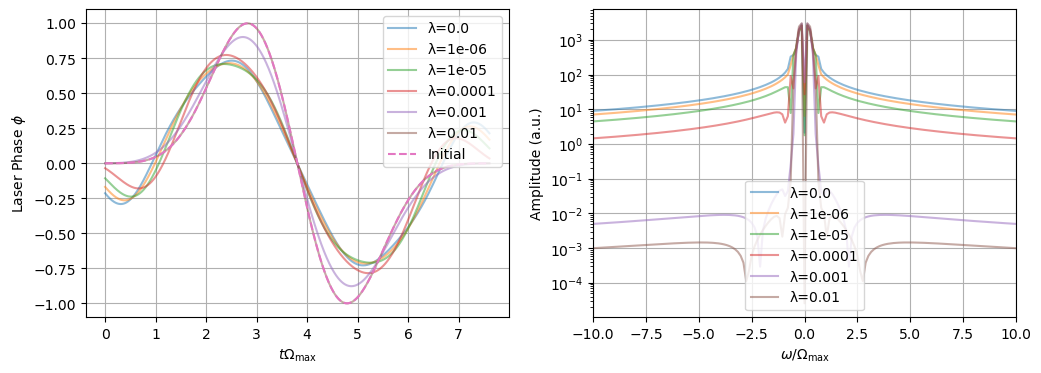

In [77]:
# evaluate fidelities of optimized gates
for i in range(len(bw_lambdas)):
    infidelity, _ = goat_optimizer.evaluate_function(HaarAverageInfidelity(), eval_params=opt_results[i].x, target_unitary=target_unitary)
    print(f"λ={bw_lambdas[i]}, 1-F = {infidelity}")

# plot laser phase profiles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ts = np.linspace(0, t_max, 10001)
for i in range(len(bw_lambdas)):
    sign = -1 if i == 4 else 1
    ax1.plot(ts, sign * get_slepval(ts, opt_results[i].x[:-1]), alpha=0.5, label=f"λ={bw_lambdas[i]}")
ax1.plot(ts, get_slepval(ts, params_0[:-1]), linestyle="--", label="Initial")
ax1.set_xlabel("$t\\Omega_{\\text{max}}$")
ax1.set_ylabel("Laser Phase $\\phi$")
ax1.legend()
ax1.grid()

# compute and plot Fourier transforms of gates
for i in range(len(bw_lambdas)):
    n_samples = 10001
    slepian_phase_func = lambda t: get_slepval(t, opt_results[i].x[:-1])
    phase_samples = np.array([slepian_phase_func(t) for t in np.linspace(0, t_max, n_samples)])
    freqs = np.fft.fftshift(np.fft.fftfreq(n_samples, d=t_max / n_samples))
    S = np.fft.fftshift(np.fft.fft(phase_samples))
    ax2.semilogy(freqs, np.abs(S), alpha=0.5, label=f"λ={bw_lambdas[i]}")

ax2.set_xlim(-10, 10)
ax2.set_xlabel("$\\omega/\\Omega_{\\text{max}}$")
ax2.set_ylabel("Amplitude (a.u.)")
ax2.legend()
ax2.grid()

plt.show()

The fidelities and Fourier transform plot above reveal that as $\lambda$ increases, the optimzed pulses are indeed more localized in the frequency domain, but their fidelity decreases. This once again reveals a tradeoff between high-fidelity and low-bandwidth pulses, and by tuning $\lambda$, an experimenter can achieve the right balance for their experiment. 

# References
[1] S. Machnes, E. Ass´emat, D. Tannor, and F. K. Wilhelm, “Tunable, Flexible, and Effcient
Optimization of Control Pulses for Practical Qubits”, Physical Review Letters 120,
150401 (2018).

[2] S. Jandura and G. Pupillo, “Time-Optimal Two- and Three-Qubit Gates for Rydberg
Atoms”, Quantum 6, arXiv:2202.00903 [quant-ph], 712 (2022).

[3] S. Jandura, J. D. Thompson, and G. Pupillo, “Optimizing Rydberg Gates for Logical-Qubit
Performance”, PRX Quantum 4, 020336 (2023).